# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np


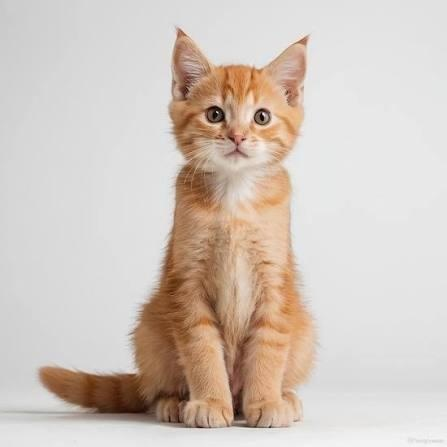

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("catim.jpg")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image

# scaling factors
width, height = img.size

cx = 2
cy = 2

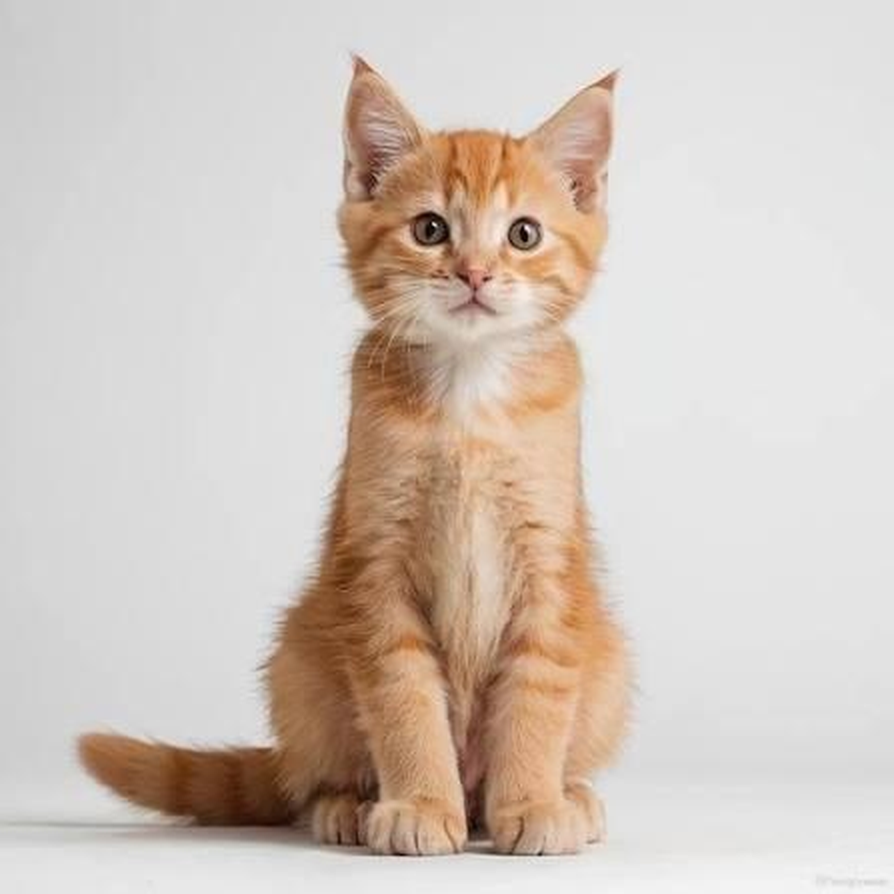

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

scaled_img

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (447, 447)
Scaled size: (894, 894)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2
cy = 1

In [7]:
new_width = int(width * cx)
new_height = int(height * cy)

stretched_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

Original size: (447, 447)
Stretched size: (894, 447)


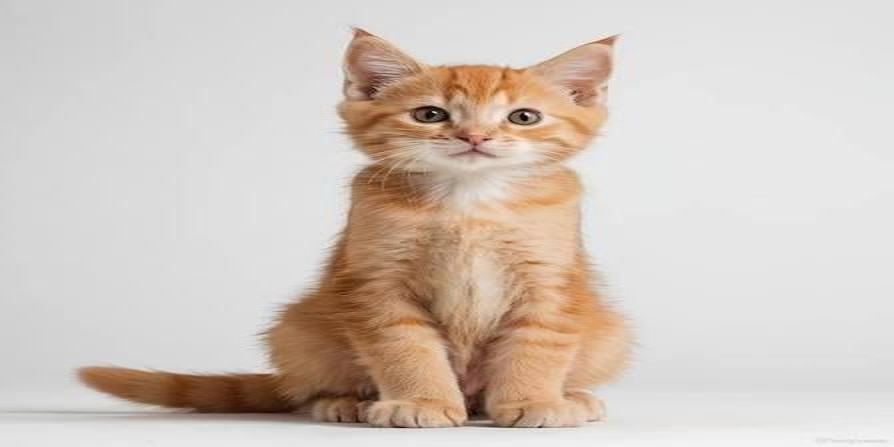

In [8]:
stretched_img.save("task1_1_stretched.jpg")

print("Original size:", img.size)
print("Stretched size:", stretched_img.size)

stretched_img

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (447, 447)
Rotated size: (611, 611)


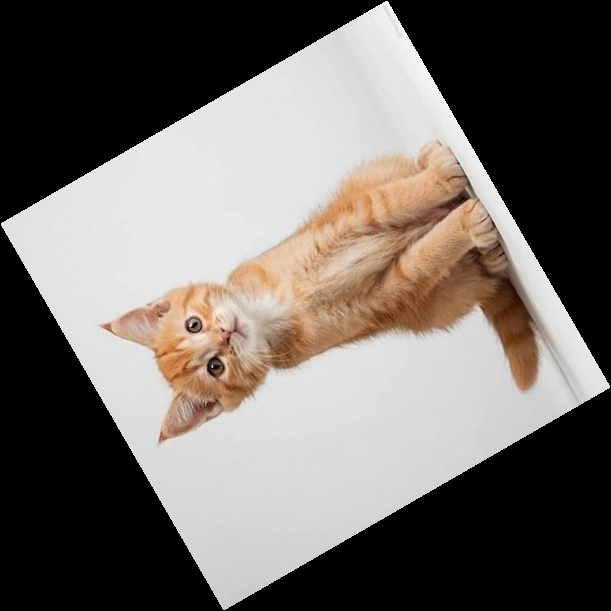

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

rotated_img

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print("Width:", width)
print("Height:", height)

Width: 447
Height: 447


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

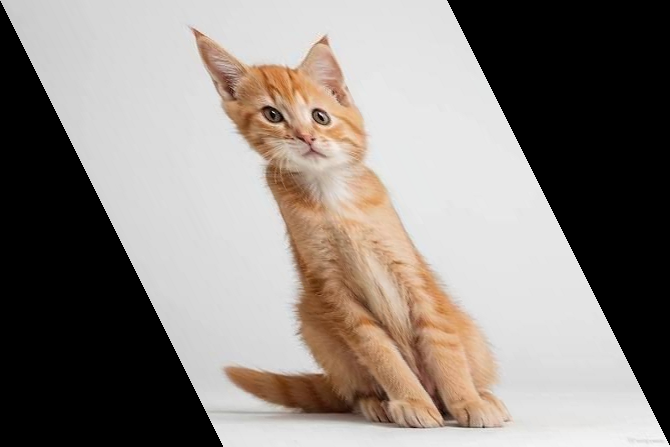

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

sheared_img

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (447, 447)
Sheared size: (670, 447)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

X-axis shear factor: 0.1


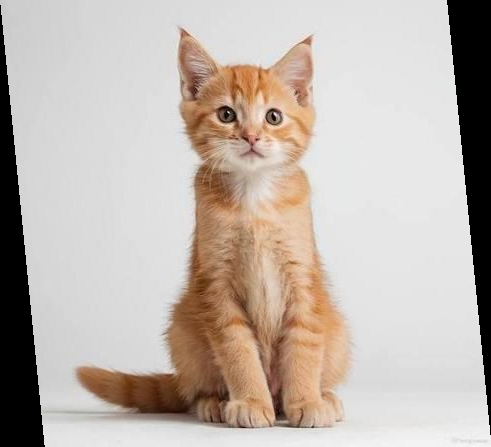

X-axis shear factor: 0.3


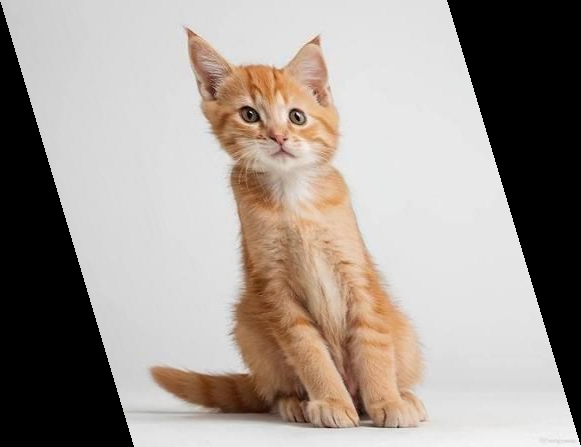

X-axis shear factor: 0.8


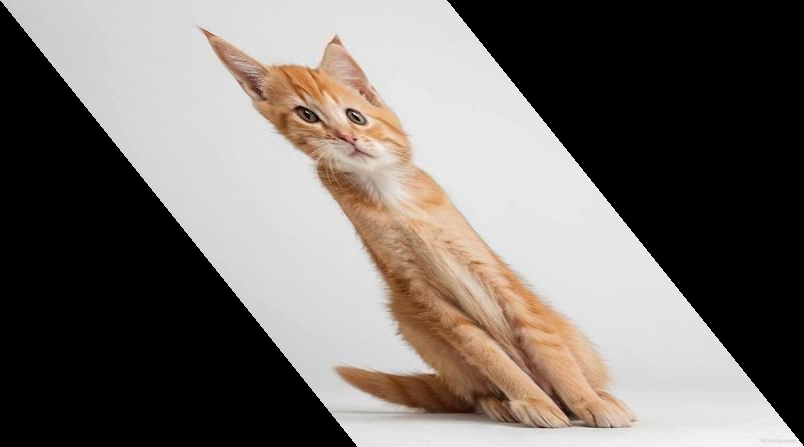

Y-axis shear factor: 0.5


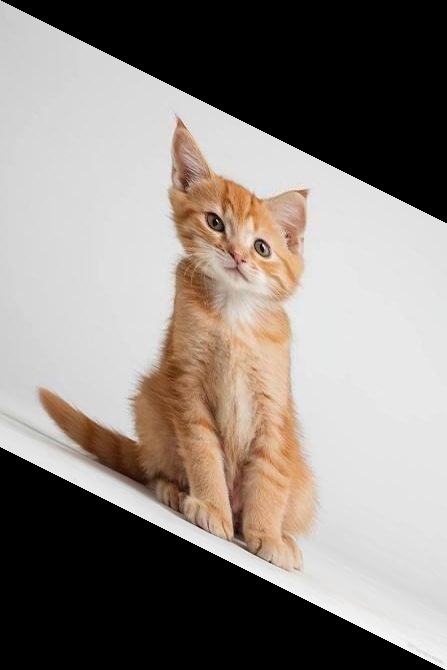

Combined shear: shx = 0.3 , shy = 0.2


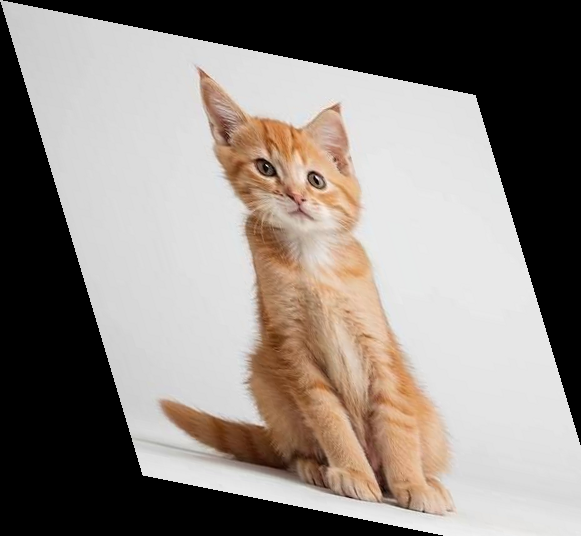

In [14]:
# Compare different X-axis shear factors
shear_values = [0.1, 0.3, 0.8]

for shx in shear_values:
    new_width = int(width + abs(shx) * height)

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -shx, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    print("X-axis shear factor:", shx)
    display(result)

# Y-axis shear
shx = 0
shy = 0.5
new_width = width
new_height = int(height + abs(shy) * width)

y_sheared = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("Y-axis shear factor:", shy)
display(y_sheared)

# Combine X and Y shear
shx = 0.3
shy = 0.2
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

print("Combined shear: shx =", shx, ", shy =", shy)
display(combined_shear)


# Intensity Transformations
Negative · Log · Power Law (Gamma)

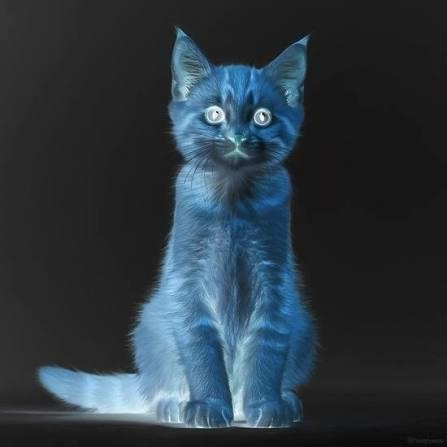

In [15]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array)

negative_img.save("task2_1_negative_numpy.jpg")

negative_img

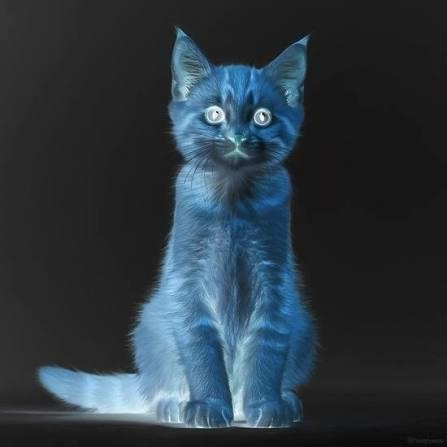

In [16]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img.convert("RGB"))

negative_img2.save("task2_1_negative_imageops.jpg")

negative_img2

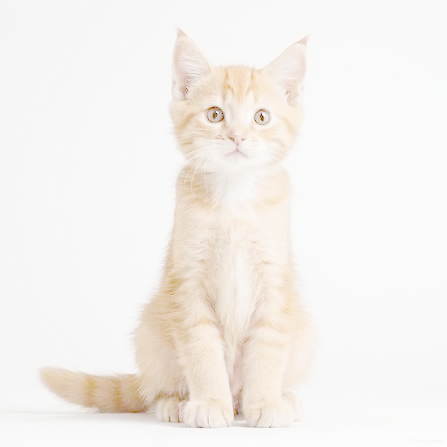

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
img_array = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)

log_array = c * np.log(1 + img_array)

log_array = np.uint8(log_array)

log_img = Image.fromarray(log_array)

log_img.save("task2_2_log.jpg")

log_img

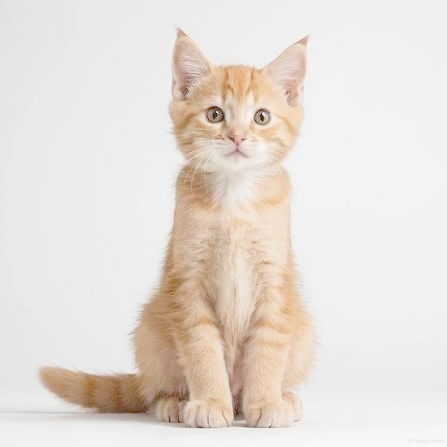

In [18]:

# ── 3. Power-law / Gamma correction ───────────────
img_array = np.array(img).astype(np.float32) / 255.0

gamma = 0.5

gamma_array = 255 * (img_array ** gamma)

gamma_array = np.uint8(gamma_array)

gamma_img = Image.fromarray(gamma_array)

gamma_img.save("task2_3_gamma_05.jpg")

gamma_img

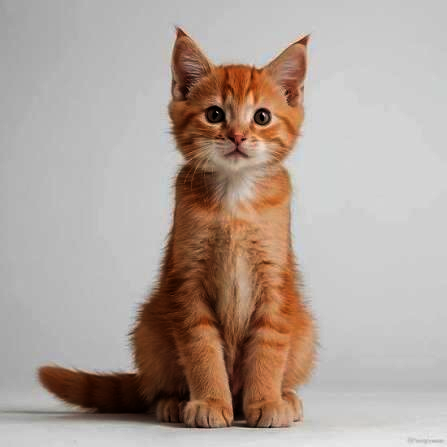

In [19]:
gamma = 2.0

gamma_array2 = 255 * (img_array ** gamma)

gamma_array2 = np.uint8(gamma_array2)

gamma_img2 = Image.fromarray(gamma_array2)

gamma_img2.save("task2_3_gamma_20.jpg")

gamma_img2